<a href="https://colab.research.google.com/github/Gurram-Mohan/ML-Project/blob/main/ML_Project_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Air Quality Index Prediction using Machine Learning
# Model: XGBoost Regressor


## 231FA04441 - B. Mahidhar
## 231FA04473 - Nikhil Sumanth
## 231FA04569 - Gurram Mohan


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/dataset finnal.csv')
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,01-01-2015,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,02-01-2015,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,03-01-2015,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,04-01-2015,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,05-01-2015,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
# Remove unwanted columns
df = df.drop(columns=['country','state','city','station','last_update'], errors='ignore')

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df = df.fillna(df.median(numeric_only=True))

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,01-01-2015,67.450578,118.127103,0.92,18.22,17.15,23.483476,0.92,27.64,133.36,0.00,0.02,0.00,166.463581,NaN
1,Ahmedabad,02-01-2015,67.450578,118.127103,0.97,15.69,16.46,23.483476,0.97,24.55,34.06,3.68,5.50,3.77,166.463581,NaN
2,Ahmedabad,03-01-2015,67.450578,118.127103,17.40,19.30,29.70,23.483476,17.40,29.07,30.70,6.80,16.40,2.25,166.463581,NaN
3,Ahmedabad,04-01-2015,67.450578,118.127103,1.70,18.48,17.97,23.483476,1.70,18.59,36.08,4.43,10.14,1.00,166.463581,NaN
4,Ahmedabad,05-01-2015,67.450578,118.127103,22.10,21.42,37.76,23.483476,22.10,39.33,39.31,7.01,18.89,2.78,166.463581,NaN


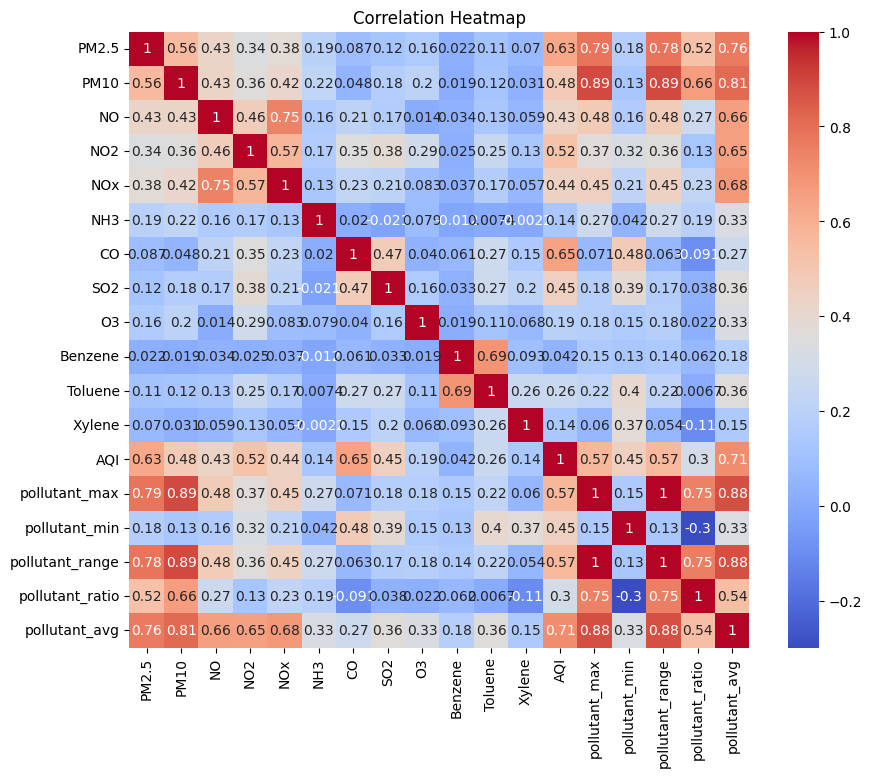

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
df['pollutant_max'] = df[pollutant_cols].max(axis=1)
df['pollutant_min'] = df[pollutant_cols].min(axis=1)

df['pollutant_range'] = df['pollutant_max'] - df['pollutant_min']
df['pollutant_ratio'] = df['pollutant_max'] / (df['pollutant_min'] + 1)

In [ ]:
df['pollutant_avg'] = df[pollutant_cols].mean(axis=1)

y = df['pollutant_avg']   # target (AQI)
X = df.drop(columns=['pollutant_avg'])

**Mutual Information Feature Selection
Mutual Information is used to select important features that influence AQI**

In [ ]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

# Drop non-numeric and categorical columns from X before calculating mutual information
X_numeric = X.drop(columns=['City', 'Date', 'AQI_Bucket'], errors='ignore')

mi = mutual_info_regression(X_numeric, y)

mi_df = pd.DataFrame({
    'Feature': X_numeric.columns,
    'MI Score': mi
}).sort_values(by='MI Score', ascending=False)

print(mi_df)

            Feature  MI Score
15  pollutant_range  1.133300
13    pollutant_max  0.967796
1              PM10  0.787000
0             PM2.5  0.773954
12              AQI  0.737684
16  pollutant_ratio  0.619563
4               NOx  0.519881
3               NO2  0.497851
2                NO  0.477440
6                CO  0.384217
14    pollutant_min  0.310143
7               SO2  0.303269
5               NH3  0.267005
8                O3  0.252549
10          Toluene  0.241959
9           Benzene  0.231531
11           Xylene  0.159232


In [ ]:
X = X_numeric[mi_df[mi_df['MI Score'] > 0.01]['Feature']]

In [ ]:
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

X = X.drop(columns=pollutant_cols, errors='ignore')

**Variance Inflation Factor (VIF)
VIF is used to remove multicollinearity between features.**

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

def remove_vif(X):
    while True:
        vif = pd.DataFrame()
        vif["Feature"] = X.columns
        vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

        if vif['VIF'].max() > 10:
            drop_feature = vif.sort_values('VIF', ascending=False)['Feature'].iloc[0]
            X = X.drop(columns=[drop_feature])
        else:
            break
    return X

X = remove_vif(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=7,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

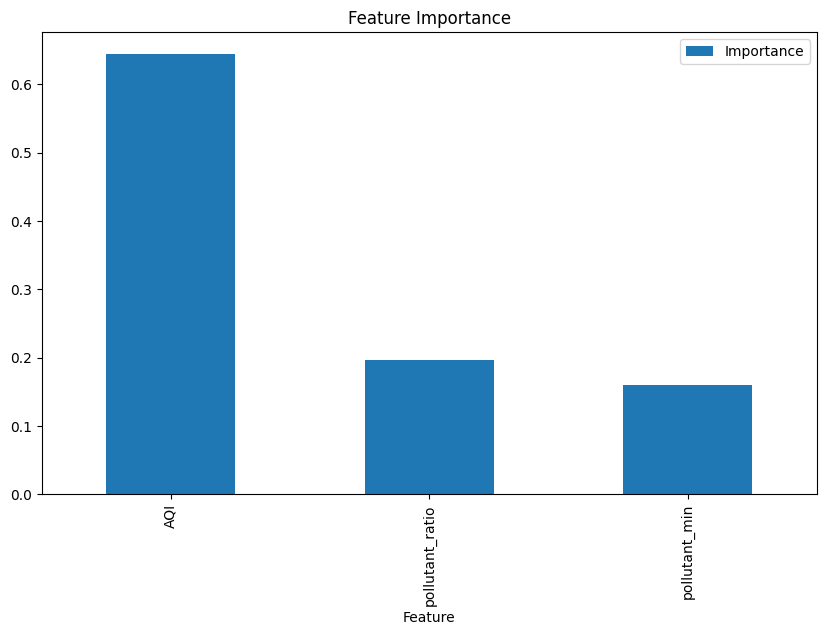

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feat_imp.plot(kind='bar', x='Feature', y='Importance', figsize=(10,6))
plt.title("Feature Importance")
plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

R2 Score: 0.8624587220310372
RMSE: 5.636838242140522


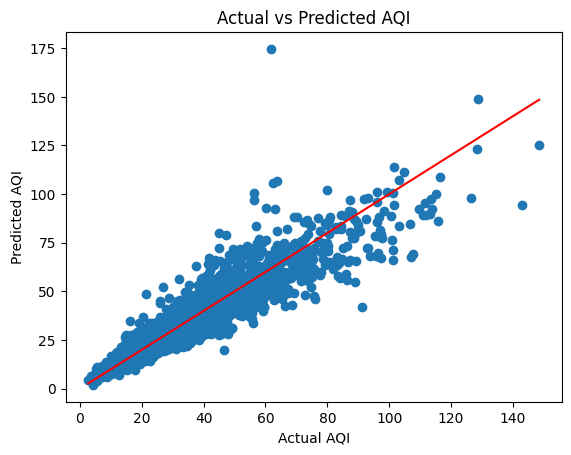

In [ ]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.show()

## Conclusion

The model successfully predicts AQI using pollutant data.
Feature selection techniques like Mutual Information and VIF improved performance.
XGBoost achieved an R² score of 0.86, indicating strong predictive capability.